Barplot pour visualier les configurations

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

In [55]:
#import des résultats

grid_classique = pd.read_csv("/autofs/unityaccount/cremi/leanguye/projet-deep-learning-m1/resnet18/src/resnet18_RGB/results/grid_search_results.csv")
grid_par_classe = pd.read_csv("/autofs/unityaccount/cremi/leanguye/projet-deep-learning-m1/resnet18/src/resnet18_RGB/results/grid_search_results_par_classe.csv")

In [ ]:
#pour sélectionner la colonne config
print(grid_classique['config'])
print(grid_par_classe['config'])

0     config0_epochs50_lr0.001_optAdam_schedStepLR_s...
1     config1_epochs50_lr0.001_optAdam_schedStepLR_s...
2     config2_epochs50_lr0.001_optAdam_schedStepLR_s...
3     config3_epochs50_lr0.001_optAdam_schedStepLR_s...
4     config4_epochs50_lr0.001_optAdam_schedReduceLR...
5     config5_epochs50_lr0.001_optAdam_schedReduceLR...
6     config6_epochs50_lr0.001_optAdam_schedReduceLR...
7     config7_epochs50_lr0.001_optAdam_schedReduceLR...
8     config8_epochs50_lr0.001_optSGD_schedStepLR_st...
9     config9_epochs50_lr0.001_optSGD_schedStepLR_st...
10    config10_epochs50_lr0.001_optSGD_schedStepLR_s...
11    config11_epochs50_lr0.001_optSGD_schedStepLR_s...
12    config12_epochs50_lr0.001_optSGD_schedReduceLR...
13    config13_epochs50_lr0.001_optSGD_schedReduceLR...
14    config14_epochs50_lr0.001_optSGD_schedReduceLR...
15    config15_epochs50_lr0.001_optSGD_schedReduceLR...
16    config16_epochs50_lr0.0001_optAdam_schedStepLR...
17    config17_epochs50_lr0.0001_optAdam_schedSt

In [ ]:
config_classique = grid_classique['config'].str.extract(r'(config\d+)') [0] #.str ne fonctionne que sur une Series (une seule colonne).
config_par_classe = grid_par_classe['config'].str.extract(r'(config\d+)') [0]

#autre manière de faire : labels = [f"c{i}" for i in range(len(df_random))] mais ne permet pas de s'assurer que c'est la bonne config



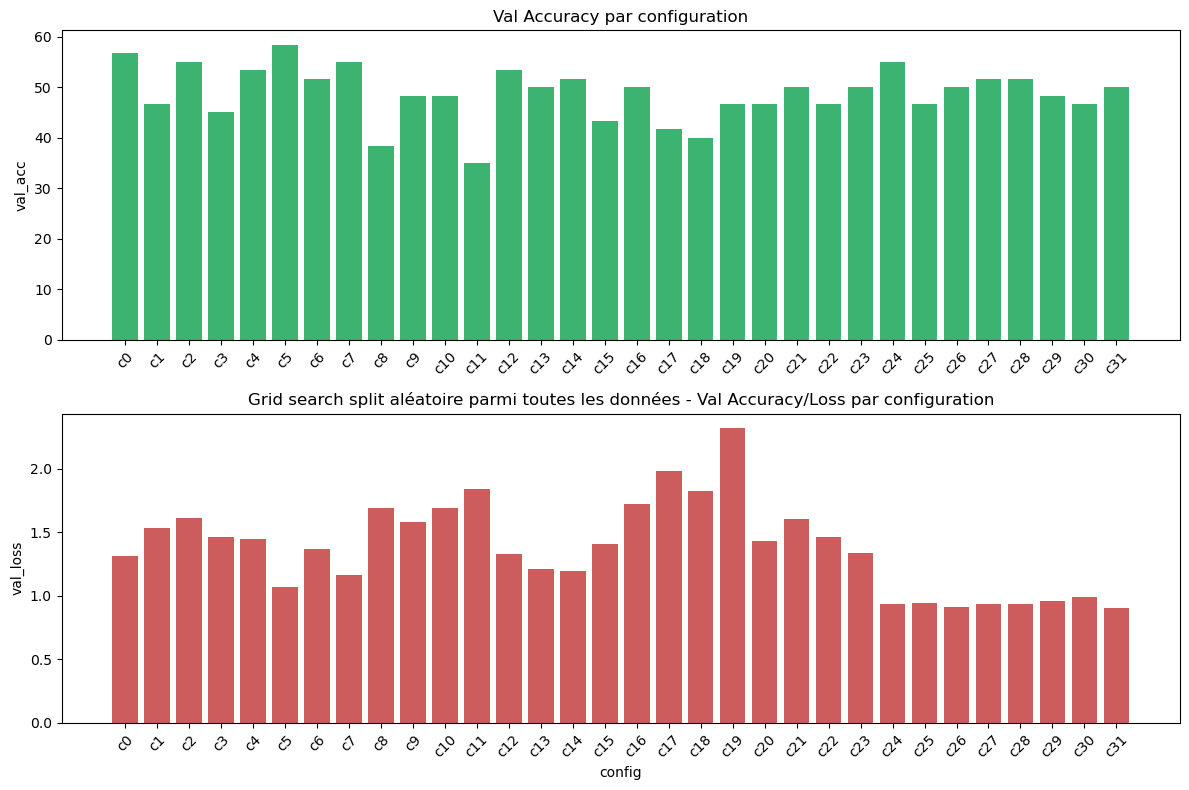

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#Accuracy

axes[0].bar(config_classique, grid_classique['val_acc'], color="mediumseagreen")
axes[0].set_title("Val Accuracy par configuration")
axes[0].set_ylabel("val_acc")
axes[0].tick_params(axis='x', rotation=45)

#Loss
axes[1].bar(config_classique, grid_classique['val_loss'], color='indianred')
axes[1].set_title("Val Loss par configuration")
axes[1].set_xlabel("config")
axes[1].set_ylabel("val_loss")
axes[1].tick_params(axis='x', rotation=45)

plt.title("Grid search split aléatoire parmi toutes les données - Val Accuracy/Loss par configuration")

plt.tight_layout() #pour que les labels ne se chevauchent pas
plt.show()



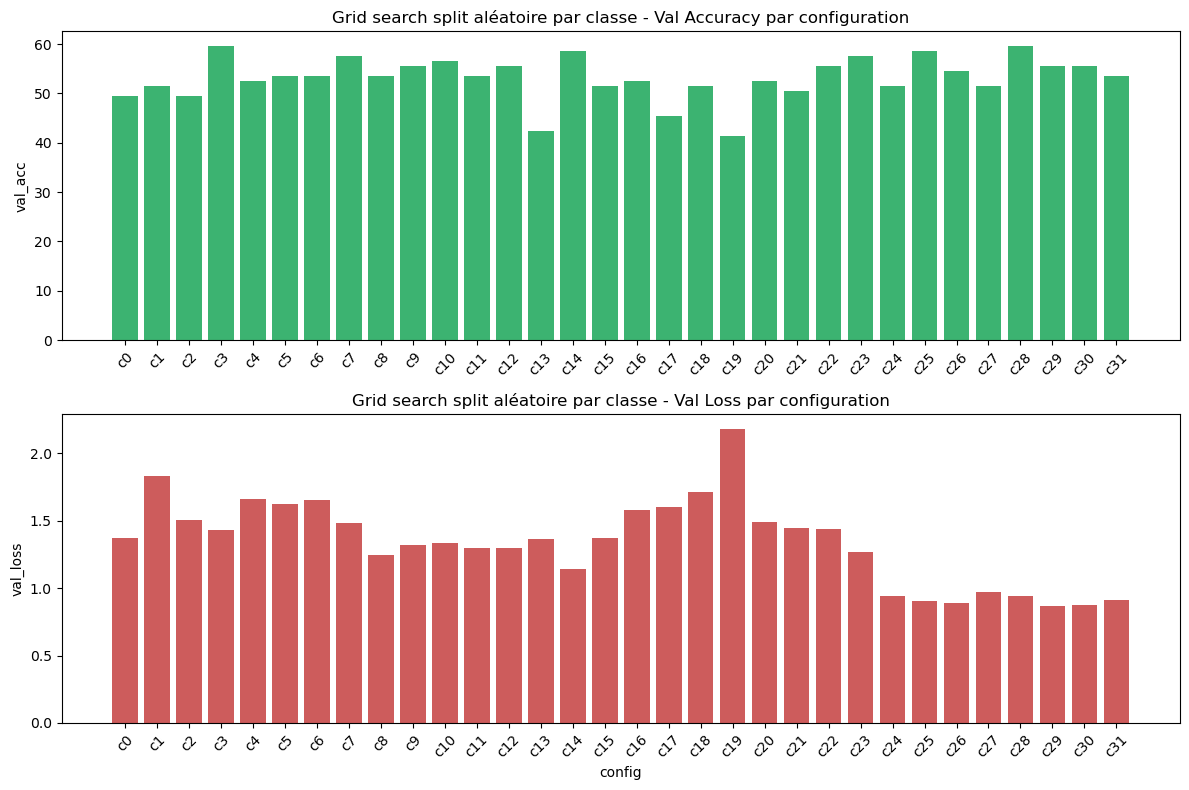

In [82]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#Accuracy

axes[0].bar(config_par_classe, grid_par_classe['val_acc'], color="mediumseagreen")
axes[0].set_title("Grid search split aléatoire par classe - Val Accuracy par configuration")
axes[0].set_ylabel("val_acc")
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(config_par_classe, grid_par_classe['val_loss'], color='indianred')
axes[1].set_title("Grid search split aléatoire par classe - Val Loss par configuration")
axes[1].set_xlabel("config")
axes[1].set_ylabel("val_loss")
axes[1].tick_params(axis='x', rotation=45)

#plt.title("Grid search split aléatoire par classe - Val Accuracy/Loss par configuration")

plt.tight_layout() #pour que les labels ne se chevauchent pas
plt.show()

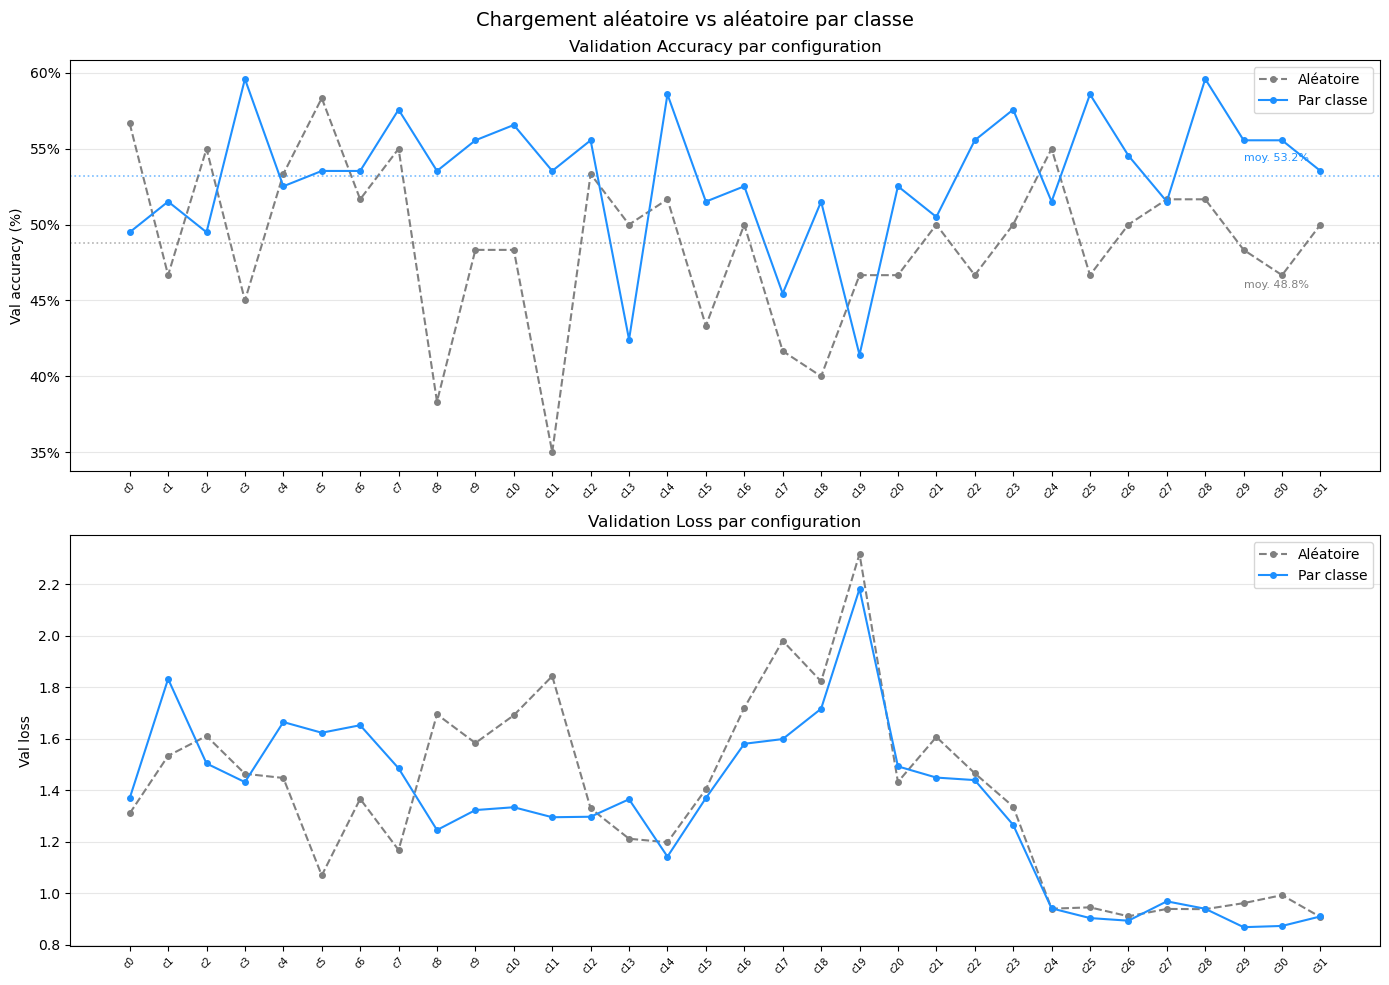

In [78]:
#CLAUDE 

labels = [f"c{i}" for i in range(len(grid_classique))]
 
# --- Figure 1 : val_acc comparaison ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Chargement aléatoire vs aléatoire par classe", fontsize=14)
 
ax1 = axes[0]
ax1.plot(labels, grid_classique["val_acc"], color="grey", linestyle="--", marker="o", markersize=4, label="Aléatoire")
ax1.plot(labels, grid_par_classe["val_acc"],  color="dodgerblue", linestyle="-",  marker="o", markersize=4, label="Par classe")
ax1.axhline(grid_classique["val_acc"].mean(), color="grey", linestyle=":", alpha=0.6, linewidth=1.2) #alpha controle la transparence
ax1.axhline(grid_par_classe["val_acc"].mean(),  color="dodgerblue", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.set_ylabel("Val accuracy (%)")
ax1.set_title("Validation Accuracy par configuration")
ax1.legend()
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, fontsize=7)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.grid(axis="y", alpha=0.3) 
 
# Annotations moyennes
ax1.annotate(f"moy. {grid_classique['val_acc'].mean():.1f}%", xy=(31, grid_classique["val_acc"].mean()),
             xytext=(29, grid_classique["val_acc"].mean() - 3), color="grey", fontsize=8)
ax1.annotate(f"moy. {grid_par_classe['val_acc'].mean():.1f}%", xy=(31, grid_par_classe["val_acc"].mean()),
             xytext=(29, grid_par_classe["val_acc"].mean() + 1), color="dodgerblue", fontsize=8)
 
# --- Figure 2 : val_loss comparaison ---
ax2 = axes[1]
ax2.plot(labels, grid_classique["val_loss"], color="grey", linestyle="--", marker="o", markersize=4, label="Aléatoire")
ax2.plot(labels, grid_par_classe["val_loss"],  color="dodgerblue", linestyle="-",  marker="o", markersize=4, label="Par classe")
ax2.set_ylabel("Val loss")
ax2.set_title("Validation Loss par configuration")
ax2.legend()
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, fontsize=7)
ax2.grid(axis="y", alpha=0.3)


 
plt.tight_layout()
plt.savefig("comparison_val_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
summary = pd.DataFrame({
    "Méthode":         ["Aléatoire",  "Par classe"],
    "Val acc max":     [grid_classique["val_acc"].max(), grid_par_classe["val_acc"].max()],
    "Val acc moy":     [grid_classique["val_acc"].mean(), grid_par_classe["val_acc"].mean()],
    "Val loss min":    [grid_classique["val_loss"].min(), grid_par_classe["val_loss"].min()],
    "Val loss moy":    [grid_classique["val_loss"].mean(),grid_par_classe["val_loss"].mean()],
})
print(summary.to_string(index=False))



   Méthode  Val acc max  Val acc moy  Val loss min  Val loss moy
 Aléatoire    58.333333    48.802083      0.906950      1.379404
Par classe    59.595960    53.188131      0.867643      1.342315
